In [5]:
import sys 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn.datasets._california_housing as california_housing
try:
    import sklearn
    from sklearn.cluster import KMeans
    from sklearn.neighbors import NearestNeighbors
    from sklearn.model_selection import train_test_split
    from sklearn.neural_network import MLPRegressor
    from sklearn.preprocessing import StandardScaler
    print("scikit-learn:", sklearn.__version__)
except Exception as e:
    print("scikit-learn not available yet:", repr(e))


scikit-learn: 1.8.0


In [ ]:
housing= california_housing.fetch_california_housing()
print(housing.data.shape, housing.target.shape , housing.DESCR)

## Each instance in the data set corresponds to a block group, (housing area)
# which is a geographical area defined by the U.S. Census Bureau. 
# Each block group contains approximately 600 to 3,000 people. 
# The dataset includes various features such as median income, average house age, average number of rooms, and more,
# which are used to predict the median house value in that block group. in $100,000s.

(20640, 8) (20640,) .. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, 

In [23]:
def plot_points(X, y, title="Dataset", xlabel="Feature 1", ylabel="Feature 2"):
    plt.figure(figsize=(5.5, 5))
    plt.scatter(X[y == 0, 0], X[y == 0, 1], s=10, label="Class 0")
    plt.scatter(X[y == 1, 0], X[y == 1, 1], s=10, label="Class 1")
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.show()
    

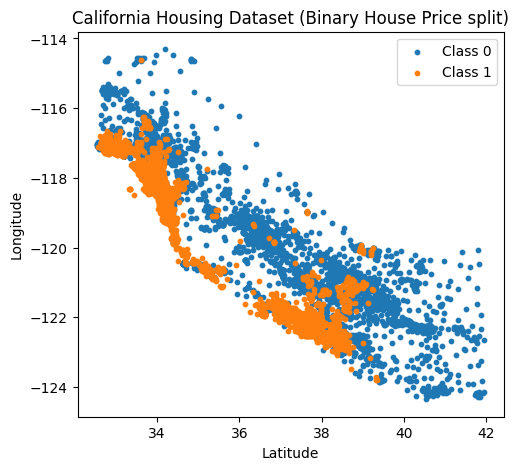

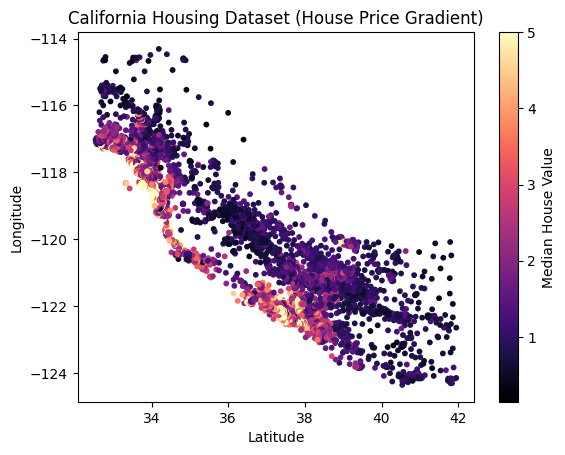

In [24]:

X = housing.data[:, [6, 7]]  # Use geographic features for visualization
y = (housing.target > 2.0).astype(int)  # Create binary labels  
plot_points(X, y, title="California Housing Dataset (Binary House Price split)", xlabel="Latitude", ylabel="Longitude")
plt.scatter(X[:, 0], X[:, 1], c=housing.target, cmap='magma', s=10)
plt.colorbar(label='Median House Value')
plt.xlabel("Latitude")
plt.ylabel("Longitude")
plt.title("California Housing Dataset (House Price Gradient)")
plt.show()

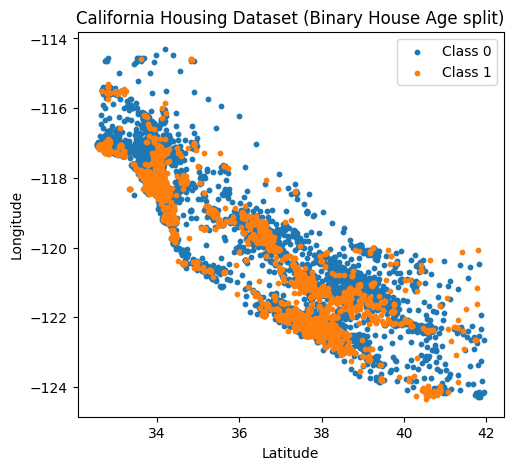

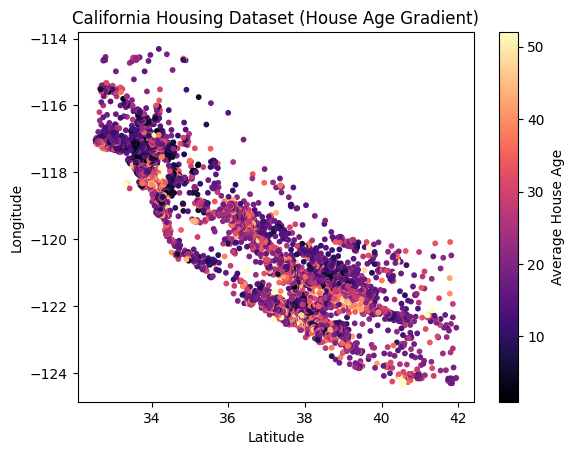

In [ ]:
y = (housing.data[:, 1] > 30).astype(int)  # Create binary labels  
plot_points(X, y, title="California Housing Dataset (Binary House Age split)", xlabel="Latitude", ylabel="Longitude")
plt.scatter(X[:, 0], X[:, 1], c=housing.data[:, 1], cmap='magma', s=10)
plt.colorbar(label='Average House Age')
plt.xlabel("Latitude")
plt.ylabel("Longitude")
plt.title("California Housing Dataset (House Age Gradient)")
plt.show()

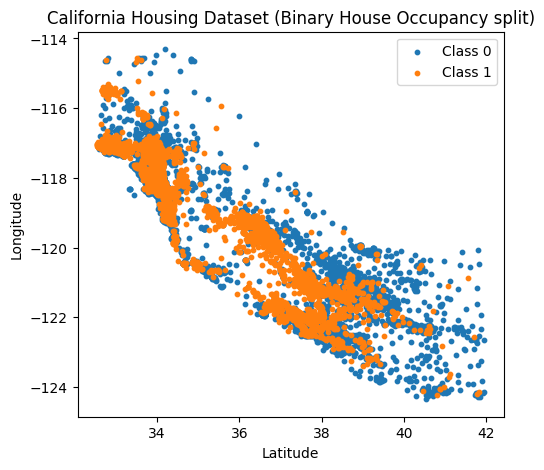

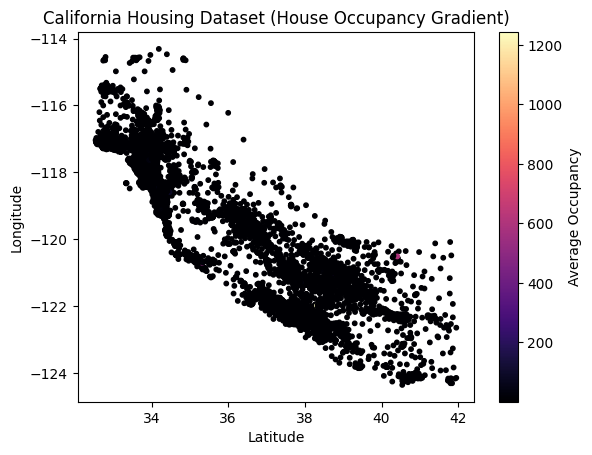

In [33]:
y = (housing.data[:, 5] > 3).astype(int)  # Create binary labels  
plot_points(X, y, title="California Housing Dataset (Binary House Occupancy split)", xlabel="Latitude", ylabel="Longitude")
plt.scatter(X[:, 0], X[:, 1], c=housing.data[:, 5], cmap='magma', s=10)
plt.colorbar(label='Average Occupancy')
plt.xlabel("Latitude")
plt.ylabel("Longitude")
plt.title("California Housing Dataset (House Occupancy Gradient)")
plt.show()

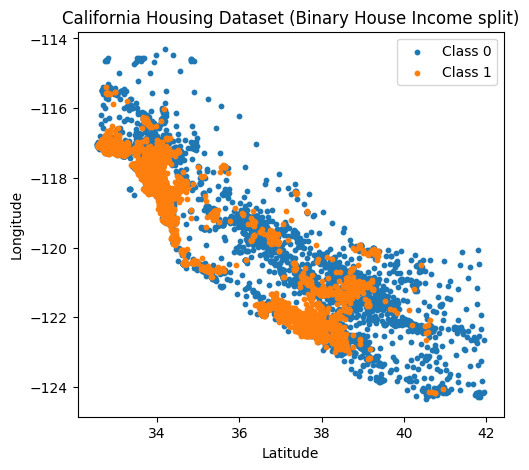

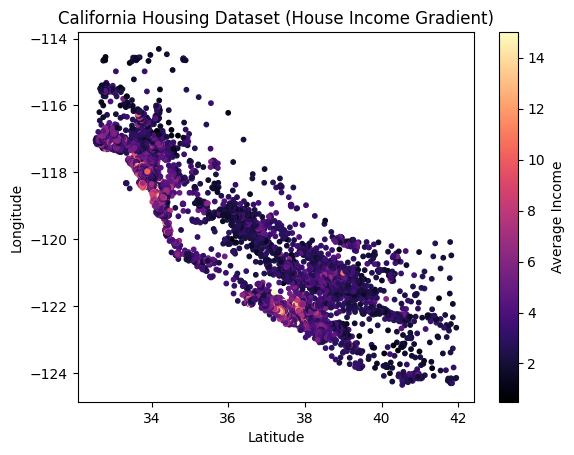

In [41]:
y = (housing.data[:, 0] > 4).astype(int)  # Create binary labels  
plot_points(X, y, title="California Housing Dataset (Binary House Income split)", xlabel="Latitude", ylabel="Longitude")
plt.scatter(X[:, 0], X[:, 1], c=housing.data[:, 0], cmap='magma', s=10)
plt.colorbar(label='Average Income')
plt.xlabel("Latitude")
plt.ylabel("Longitude")
plt.title("California Housing Dataset (House Income Gradient)")
plt.show()

In [ ]:
##Train test split
X= housing.data
y= housing.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

In [ ]:
scale = StandardScaler()

# Fit the scaler ONLY on the training data, then transform both sets
X_train_scaled = pd.DataFrame(
    scale.fit_transform(X_train), 
    columns=housing.feature_names,
)

X_test_scaled = pd.DataFrame(
    scale.transform(X_test), 
    columns=housing.feature_names,
)

In [ ]:
X_train_scaled.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,0.367714,-0.045376,0.316164,-0.134393,-0.822910,0.000795,1.289422,-1.381195
1,0.930745,-0.840169,0.209903,-0.125583,1.394248,-0.014466,-0.640792,0.483377
2,-1.127069,1.464730,-0.711852,-0.130613,0.015823,0.079913,-0.729807,0.678333
3,0.395713,0.590458,-0.117528,-0.226679,-0.394696,-0.058279,-0.781342,0.773311
4,-0.754294,1.623688,-0.554621,-0.314356,-0.025760,0.114719,-0.725122,0.683331


Cluster centroids (scaled):
 [[-1.19699896  1.3122311 ]
 [ 0.96190858 -1.21297992]
 [-0.75777206  0.72180873]
 [ 1.70279492 -1.08247761]
 [ 0.17912253 -0.0675343 ]]
Inertia: 2440.419828861569


Text(0.5, 1.0, 'K-Means Clustering of California Housing (Scaled)')

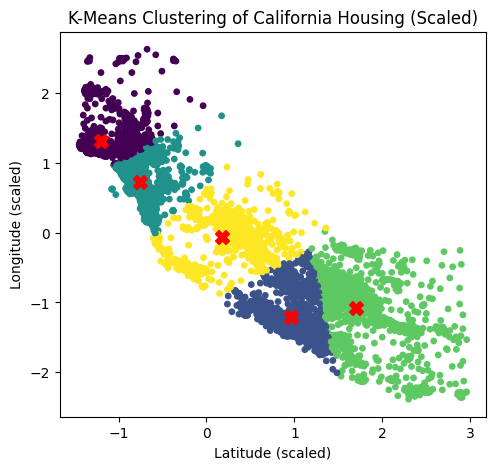

In [ ]:
X = housing.data[:, [6, 7]]  # Use geographic features for clustering

kmeans = KMeans(n_clusters=5, n_init='auto', random_state=123) # Initialize KMeans with 5 clusters and a fixed random state for reproducibility
labels = kmeans.fit_predict(X_train_scaled) # Fit KMeans and get cluster labels for each data point
centroids = kmeans.cluster_centers_ # Get the coordinates of the cluster centroids
inertia = kmeans.inertia_ # Get the inertia (sum of squared distances to the nearest cluster center) to evaluate clustering performance

# Print the results
print("Cluster centroids (scaled):\n", centroids)
print("Inertia:", inertia) 
plt.figure(figsize=(5.5, 5))
plt.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], c=labels, s=15, cmap='viridis')
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=100, marker='X', label='Centroids')
plt.xlabel("Latitude (scaled)")
plt.ylabel("Longitude (scaled)")
plt.title("K-Means Clustering of California Housing (Scaled)")

In [ ]:
# Defining neighbourhood relationships and average price of neighbors using KNN for geographical features (latitude and longitude) (physical proximity neighbours).
coords_train = X_train[:, [6, 7]]  # latitude, longitude (feature indices 6 & 7) to get the coordinates for the training set

knn = NearestNeighbors(n_neighbors=11) # to find the 10 nearest neighbors for each instance
knn.fit(coords_train) # fit the model on the training data coordinates

distance_train, index_train = knn.kneighbors(coords_train) # get the distances and indices of the 10 nearest neighbors for each training instance
index_train = index_train[:, 1:] # remove the first column which is the instance itself (distance 0)
print("Distances to nearest neighbors (sparse matrix):\n", distance_train) 

avg_neigh_price_train = np.array([
    y_train[index_train[i]].mean()
    for i in range(len(index_train))
])
#This gives us the average price of the 10 nearest neighbors for each training instance
print("Average neighbor prices (training set):\n", avg_neigh_price_train)

#Test set neighbors and average price of neighbors
coords_test = X_test[:, [6, 7]]  # latitude, longitude to get the coordinates for the test set

distances, index_test = knn.kneighbors(coords_test, n_neighbors=10) # get the distances and indices of the 10 nearest neighbors for each test instance
print("Distances to nearest neighbors (sparse matrix):\n", distances) 

avg_neighbour_price = np.array([
    y_train[index_test[i]].mean() 
    for i in range(len(index_test))
])  
# This gives us the average price of the 10 nearest neighbors for each test instance, using the training set prices

print("Average neighbor prices (test set):\n", avg_neighbour_price)   

# Now we can use the average neighbor prices as a feature for our MLP regressor and see if it improves our predictions. 
# We can add this as an additional feature to our training and test sets.

#mlp = MLPRegressor(hidden_layer_sizes=(100,), max_iter=500, random_state=123)
#mlp.fit(X_train_scaled, y_train)

Distances to nearest neighbors (sparse matrix):
 [[0.         0.01       0.03162278 ... 0.05       0.0509902  0.05385165]
 [0.         0.01       0.01414214 ... 0.03       0.03162278 0.03162278]
 [0.         0.         0.         ... 0.01       0.01       0.01      ]
 ...
 [0.         0.01       0.02       ... 0.02828427 0.02828427 0.03      ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.01       0.01       ... 0.04472136 0.06324555 0.06324555]]
Average neighbor prices (training set):
 [2.3118   2.5319   1.5883   ... 3.483502 3.3945   0.6172  ]
Distances to nearest neighbors (sparse matrix):
 [[0.         0.01       0.01       ... 0.01414214 0.01414214 0.01414214]
 [0.01       0.01       0.01414214 ... 0.02236068 0.02236068 0.02236068]
 [0.01       0.01       0.02       ... 0.02828427 0.02828427 0.03      ]
 ...
 [0.01       0.01       0.01414214 ... 0.02236068 0.02828427 0.03      ]
 [0.         0.         0.         ... 0.01       0.01      

In [ ]:
# Now we can repeat for other features (Eg: average number of rooms, median income, etc.) to see if they also improve our predictions.
# Let's use the average number of rooms (feature index 3) as an additional feature. 
# We can calculate the average number of rooms for the nearest neighbors in a similar way to average neighbor price, 

ave_room_train = np.array([
    X_train[index_train[i], 3].mean()
    for i in range(len(index_train))
])
# This gives us the average number of rooms of the 10 nearest neighbors for each training instance. 

print("Average rooms in nearest neighbors (training set):\n", ave_room_train)

ave_room_test = np.array([
    X_train[index_test[i], 3].mean()
    for i in range(len(index_test))
])
# This gives us the average number of rooms of the 10 nearest neighbors for each test instance, using the training set data.

print("Average rooms in nearest neighbors (test set):\n", ave_room_test)



Average rooms in nearest neighbors (training set):
 [1.05552328 1.06089949 1.05921362 ... 1.03852818 1.08048813 1.05008553]
Average rooms in nearest neighbors (test set):
 [1.03002757 1.04901101 0.99766476 ... 1.02292014 1.08749415 1.02995724]


In [ ]:
# Let's now look at the median income (feature index 0) as an additional feature.

med_income_train = np.array([
    X_train[index_train[i], 0].mean()
    for i in range(len(index_train))
])

print("Average median income of nearest neighbors (training set):\n", med_income_train)


med_income_test= np.array([
    X_train[index_test[i], 0].mean()
    for i in range(len(index_test))
])

print("Average median income of nearest neighbors (test set):\n", med_income_test)

Average median income of nearest neighbors (training set):
 [4.61594 4.67291 2.22083 ... 6.64033 2.88339 2.37129]
Average median income of nearest neighbors (test set):
 [3.59254 2.64714 4.19204 ... 2.52141 3.04313 4.26383]
